Notebook to evaluate the ranking of the retrievers

In [2]:
import ir_datasets

In [1]:
DATASET_NAME = "beir/arguana"   # e.g. "beir/fiqa", "beir/scifact", etc.


In [3]:
# -------------------------------
# 1️⃣ Load dataset dynamically
# -------------------------------
dataset = ir_datasets.load(DATASET_NAME)
print(f"Loaded {DATASET_NAME}")
print(f"Docs: {dataset.docs_count()}, Queries: {dataset.queries_count()}")

Loaded beir/arguana
Docs: 8674, Queries: 1406


In [4]:
# -------------------------------
# 2 Load qrels (for evaluation)
# -------------------------------
qrels = {}
for r in dataset.qrels_iter():
    qrels.setdefault(str(r.query_id), {})[str(r.doc_id)] = int(r.relevance)

# Sparse

In [5]:
import numpy as np
from collections import defaultdict
import math

# -------------------------------
# 1️⃣ Functions: MRR@10 and nDCG@10
# -------------------------------
def mrr_at_k_sparse(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0


def ndcg_at_k_sparse(run, qrels, k=10):
    def dcg(rels):
        return sum((rel / math.log2(i + 2)) for i, rel in enumerate(rels))

    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        v = (dcg(rels) / idcg) if idcg > 0 else 0.0
        vals.append(v)
    return float(np.mean(vals)) if vals else 0.0
    
def precision_at_k_sparse(run, qrels, k=10):
    precisions = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        precisions.append(sum(rels) / len(rels) if rels else 0)
    return float(np.mean(precisions)) if precisions else 0.0


def recall_at_k_sparse(run, qrels, k=100):
    recalls = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        total_rel = len([d for d in relset if relset[d] > 0])
        if total_rel == 0:
            continue
        rels = [1 if relset.get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        recalls.append(sum(rels) / total_rel)
    return float(np.mean(recalls)) if recalls else 0.0


def map_at_k_sparse(run, qrels, k=1000):
    ap_scores = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        num_rel = 0
        score = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                num_rel += 1
                score += num_rel / i
        if num_rel > 0:
            ap_scores.append(score / num_rel)
    return float(np.mean(ap_scores)) if ap_scores else 0.0



# -------------------------------
# 2️⃣ Load run file (.trec)
# -------------------------------
def load_sparse_run(file_path):
    run_records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue  # skip malformed lines
            qid, _, docid, _, score, _ = parts
            run_records.append((qid, docid, float(score)))
    return run_records


# -------------------------------
# 3️⃣ Convert to grouped format
# -------------------------------
def group_run_records(run_records):
    run_per_q = defaultdict(list)
    for qid, docid, score in run_records:
        run_per_q[qid].append((docid, score))
    for qid in run_per_q:
        run_per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return run_per_q





In [6]:
# -------------------------------
# 📊 Unified Evaluation Function
# -------------------------------
def evaluate_sparse_metrics(qrels, DATASET_NAME):
    RUN_PATH = f"runs/run_bm25_{DATASET_NAME.replace('/', '_')}.trec"
    run_records = load_sparse_run(RUN_PATH)
    run_per_q = group_run_records(run_records)

    metrics = {
        "nDCG@10": ndcg_at_k_sparse(run_per_q, qrels, k=10),
        "MRR@10": mrr_at_k_sparse(run_per_q, qrels, k=10),
        "Precision@10": precision_at_k_sparse(run_per_q, qrels, k=10),
        "Recall@100": recall_at_k_sparse(run_per_q, qrels, k=100),
        "MAP@1000": map_at_k_sparse(run_per_q, qrels, k=1000),
    }

    return metrics



metrics = evaluate_sparse_metrics(qrels, DATASET_NAME)
print(f"\n📈 Results for {DATASET_NAME}:")
for k, v in metrics.items():
    print(f"  {k:<12} = {v:.4f}")


📈 Results for beir/arguana:
  nDCG@10      = 0.2695
  MRR@10       = 0.1745
  Precision@10 = 0.0573
  Recall@100   = 0.8065
  MAP@1000     = 0.2300


# Dense

In [9]:
import os
import math
import numpy as np
from collections import defaultdict

# -------------------------------
# 🧾 Load Qrels from BEIR Dataset
# -------------------------------
qrels = {}
for r in dataset.qrels_iter():
    qrels.setdefault(str(r.query_id), {})[str(r.doc_id)] = int(r.relevance)

# -------------------------------
# 📥 Load Dense Retriever Run (.trec)
# -------------------------------
def load_dense_run(file_path):
    run_per_q = defaultdict(list)
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            qid, _, docid, rank, score, _ = parts
            run_per_q[qid].append((docid, float(score)))
    for qid in run_per_q:
        run_per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return run_per_q


# -------------------------------
# ⚙️ Metric Functions
# -------------------------------
def mrr_at_k_dense(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0


def ndcg_at_k_dense(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        vals.append((dcg(rels) / idcg) if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0


def precision_at_k_dense(run, qrels, k=10):
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        vals.append(sum(rels) / len(rels) if rels else 0)
    return float(np.mean(vals)) if vals else 0.0


def recall_at_k_dense(run, qrels, k=100):
    vals = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        total_rel = len([d for d in relset if relset[d] > 0])
        if total_rel == 0:
            continue
        rels = [1 if relset.get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        vals.append(sum(rels) / total_rel)
    return float(np.mean(vals)) if vals else 0.0


def map_at_k_dense(run, qrels, k=1000):
    ap_scores = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        num_rel = 0
        score = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                num_rel += 1
                score += num_rel / i
        if num_rel > 0:
            ap_scores.append(score / num_rel)
    return float(np.mean(ap_scores)) if ap_scores else 0.0


# -------------------------------
# 🧩 Unified Dense Evaluation
# -------------------------------
def evaluate_dense_metrics(qrels, DATASET_NAME):
    RUN_PATH = f"runs/run_dense_{DATASET_NAME.replace('/', '_')}.trec"
    run_per_q = load_dense_run(RUN_PATH)

    metrics = {
        "nDCG@10": ndcg_at_k_dense(run_per_q, qrels, k=10),
        "MRR@10": mrr_at_k_dense(run_per_q, qrels, k=10),
        "Precision@10": precision_at_k_dense(run_per_q, qrels, k=10),
        "Recall@100": recall_at_k_dense(run_per_q, qrels, k=100),
        "MAP@1000": map_at_k_dense(run_per_q, qrels, k=1000),
    }

    return metrics


# -------------------------------
# 🧪 Example Usage
# -------------------------------



metrics = evaluate_dense(qrels, DATASET_NAME)
print("\n📈 Results:")
for name, val in metrics.items():
    print(f"  {name:<12} = {val:.4f}")



📈 Results:
  nDCG@10      = 0.3715
  MRR@10       = 0.2477
  Precision@10 = 0.0761
  Recall@100   = 0.9623
  MAP@1000     = 0.2685


# Visualization

📚 Dataset: beir/arguana
  • Documents: 8,674
  • Queries:   1,406
  • Qrels:     1,406
  • Relevance Distribution: {1: 1406}


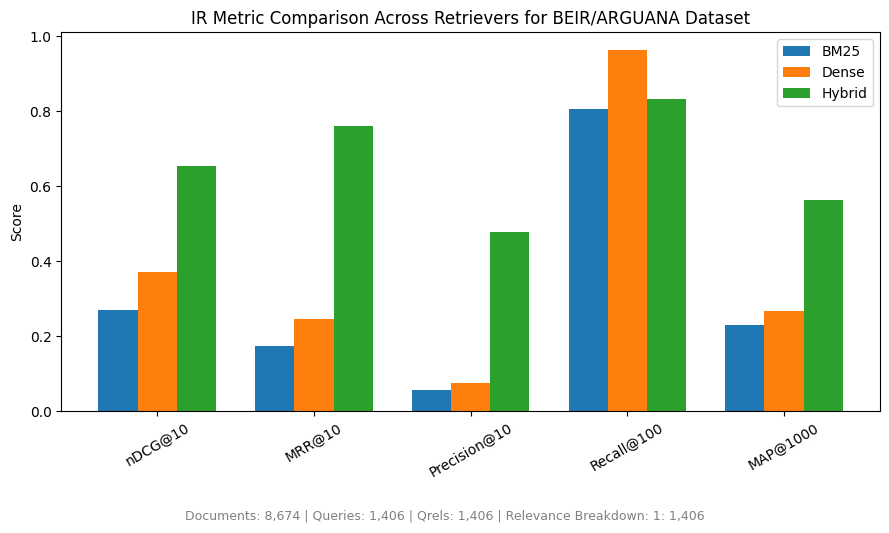

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# -------------------------------
# 🧩 1️⃣ Compute dataset metadata
# -------------------------------
def get_dataset_metadata(dataset):
    """Returns number of docs, queries, qrels, and relevance counts."""
    num_docs = sum(1 for _ in dataset.docs_iter())
    num_queries = sum(1 for _ in dataset.queries_iter())
    relevance_counts = Counter()
    num_qrels = 0
    for r in dataset.qrels_iter():
        num_qrels += 1
        relevance_counts[int(r.relevance)] += 1
    return num_docs, num_queries, num_qrels, dict(relevance_counts)

num_docs, num_queries, num_qrels, relevance_counts = get_dataset_metadata(dataset)

# -------------------------------
# 📘 Print Metadata Summary
# -------------------------------
print(f"📚 Dataset: {DATASET_NAME}")
print(f"  • Documents: {num_docs:,}")
print(f"  • Queries:   {num_queries:,}")
print(f"  • Qrels:     {num_qrels:,}")
print(f"  • Relevance Distribution: {relevance_counts}")


# -------------------------------
# 📊 2️⃣ Define retriever metrics
# -------------------------------
bm25_metrics = evaluate_sparse_metrics(qrels, DATASET_NAME)
dense_metrics = evaluate_dense_metrics(qrels, DATASET_NAME)

hybrid_metrics = {
    "nDCG@10": 0.6551,
    "MRR@10": 0.7610,
    "Precision@10": 0.4782,
    "Recall@100": 0.8320,
    "MAP@1000": 0.5624,
}


# -------------------------------
# 📈 3️⃣ Bar Chart Comparison
# -------------------------------
metrics = list(bm25_metrics.keys())
systems = ["BM25", "Dense", "Hybrid"]
values = np.array([
    [bm25_metrics[m] for m in metrics],
    [dense_metrics[m] for m in metrics],
    [hybrid_metrics[m] for m in metrics]
])

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for i, sys in enumerate(systems):
    ax.bar(x + (i - 1)*width, values[i], width, label=sys)

ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30)
ax.legend()

# ✅ Title with dataset name
ax.set_title(f'IR Metric Comparison Across Retrievers for {DATASET_NAME.upper()} Dataset')

# 📝 Metadata annotation below chart
metadata_text = (
    f"Documents: {num_docs:,} | Queries: {num_queries:,} | Qrels: {num_qrels:,} | "
    f"Relevance Breakdown: " +
    ", ".join([f"{k}: {v:,}" for k, v in relevance_counts.items()])
)

plt.figtext(0.5, -0.05, metadata_text, wrap=True,
            horizontalalignment='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()
